# 09 — Retrain classifier with synthetic augmentation (Phase 10)

**THE main experiment.** This is the chart the project exists to produce: does augmenting the training set with synthetic minority-class images, generated by our CVAE and cGAN, improve per-class recall on the real test set?

**Design (the comparison is what matters — every other choice mirrors Phase 5 exactly).**

1. **Same architecture as Phase 5** — `build_resnet50_classifier(freeze_backbone=True)`, head-only training. Anything else makes the comparison unfair.
2. **Same hyperparameters** as Phase 5 — LR, batch size, optimizer, EarlyStopping patience, augmentation pipeline (Resize→Flip→ToTensor→ImageNet-normalize). Only one variable changes: the training data.
3. **Class weights computed from REAL train counts**, not augmented counts. Reason: this isolates *the effect of more diverse data* from *the effect of louder loss weighting*. The baseline used weighted CE; we use the identical weights, so any improvement is attributable purely to the synthetic images.
4. **Val and test are real-only.** We do not validate on synthetic — that would optimise early stopping on how well we reconstruct fakes.
5. **Per-class source selection** is the one knob the user turns. Edit `SOURCES_PER_CLASS` in cell 3 based on Phase 9 FID + visual results. Default is `'both'` for the rare classes (safe starting point; pick the FID winner per class as soon as Phase 9 numbers come in).

**Outputs** (mirror the Phase 5 naming with `_augmented` suffix):
- `results/checkpoints/augmented_resnet50_best.pt`
- `results/logs/augmented_resnet50_log.csv`
- `results/plots/augmented_resnet50_curves.png`
- `results/plots/augmented_resnet50_confusion.png`
- `results/logs/comparison_baseline_vs_augmented.csv`  ← the main result table
- `results/plots/comparison_per_class_recall.png`     ← the main result figure

## 1. Setup, paths, seed

In [12]:
import sys
from pathlib import Path
import csv
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, recall_score,
)

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import ISICDataset, CLASS_NAMES, get_class_weights   # noqa: E402
from src.dataset_augmented import AugmentedISICDataset                # noqa: E402
from src.models.classifier import build_resnet50_classifier           # noqa: E402

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

RESULTS    = PROJECT_ROOT / 'results'
SPLITS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'splits.csv'
IMAGES_DIR = PROJECT_ROOT / 'data' / 'raw' / 'ISIC2018_Task3_Training_Input'
MANIFEST   = PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic_manifest.csv'
BASELINE_CKPT = RESULTS / 'checkpoints' / 'baseline_resnet50_best.pt'
BASELINE_LOG  = RESULTS / 'logs' / 'baseline_resnet50_log.csv'

(RESULTS / 'checkpoints').mkdir(parents=True, exist_ok=True)
(RESULTS / 'logs').mkdir(parents=True, exist_ok=True)
(RESULTS / 'plots').mkdir(parents=True, exist_ok=True)

assert SPLITS_CSV.exists(), f'splits.csv not found at {SPLITS_CSV}'
assert MANIFEST.exists(),   f'synthetic_manifest.csv not found at {MANIFEST}. Run Phase 8 first.'
assert BASELINE_CKPT.exists(), f'baseline checkpoint not found at {BASELINE_CKPT}. Run Phase 5 first.'
print('All inputs present')

Device: cuda
  GPU: NVIDIA A100-SXM4-80GB
All inputs present


## 2. Hyperparameters — mirrored from Phase 5

In [13]:
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 40
LR           = 1e-3
PATIENCE     = 7
NUM_WORKERS  = 4
N_CLASSES    = len(CLASS_NAMES)

# ⬇⬇⬇ THE KNOB ⬇⬇⬇
# Edit these after looking at Phase 9 FID + visual results.
# Per class: 'cvae', 'cgan', 'both', or 'none'.
# Classes not listed default to 'both'.
# Default = 'both' for the four rare classes; this is the safe starting point.
SOURCES_PER_CLASS = {
    # 0: 'none',  # MEL   — already abundant, no synthetic
    # 1: 'none',  # NV    — already abundant, no synthetic
    2: 'both',    # BCC
    3: 'both',    # AKIEC
    # 4: 'none',  # BKL   — already abundant
    5: 'both',    # DF
    6: 'both',    # VASC
}
# ⬆⬆⬆ THE KNOB ⬆⬆⬆

print(f'image size      : {IMG_SIZE}')
print(f'batch size      : {BATCH_SIZE}')
print(f'epochs          : {EPOCHS}')
print(f'lr              : {LR}')
print(f'patience        : {PATIENCE}')
print(f'sources per cls : {SOURCES_PER_CLASS}')

image size      : 224
batch size      : 32
epochs          : 40
lr              : 0.001
patience        : 7
sources per cls : {2: 'both', 3: 'both', 5: 'both', 6: 'both'}


## 3. Data — augmented train, real val/test

Identical transforms to Phase 5 (ImageNet normalization, train-time flip+rotation). The augmented dataset applies these to *both* real and synthetic samples — we do NOT want the classifier learning "synthetic == always upright" as a shortcut.

In [14]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Augmented train (real + synthetic per SOURCES_PER_CLASS)
train_ds = AugmentedISICDataset(
    splits_csv=SPLITS_CSV, images_dir=IMAGES_DIR,
    synth_manifest_csv=MANIFEST, project_root=PROJECT_ROOT,
    split='train', transform=train_tf,
    sources_per_class=SOURCES_PER_CLASS,
)
# Val and test: real only (the wrapper enforces this for split != 'train')
val_ds  = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='val',  transform=eval_tf)
test_ds = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='test', transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'AUGMENTED train : {len(train_ds)} samples  ({len(train_loader)} batches)')
print(f'val   (real)   : {len(val_ds)}  samples')
print(f'test  (real)   : {len(test_ds)} samples')
print('\nTrain composition (real vs synth per class):')
comp = train_ds.count_by_source_and_class()
comp.index = [CLASS_NAMES[i] for i in comp.index]
print(comp)

AUGMENTED train : 14377 samples  (449 batches)
val   (real)   : 1503  samples
test  (real)   : 1503 samples

Train composition (real vs synth per class):
source  real  synth
MEL      779    442
NV      4693      0
BCC      360   1280
AKIEC    229   1542
BKL      769    462
DF        80   1840
VASC      99   1802


## 4. Class weights — from REAL train counts only

Critical for the fairness of the comparison: the baseline used weighted CE with weights $w_c = N / (K \cdot n_c)$ computed on the real training set. We use the *exact same weights*. If we recomputed weights on the augmented counts, the minority classes would no longer be minority, weights would collapse to ~1, and we'd be changing *two things* between baseline and augmented (data AND loss). That's a confounded experiment.

By keeping the weights fixed, the only variable is the training data composition.

In [15]:
splits = pd.read_csv(SPLITS_CSV)
real_train = splits[splits['split'] == 'train']
label_col = 'label' if 'label' in real_train.columns else 'class_idx'
real_counts = real_train[label_col].value_counts().sort_index()

# Same formula as Phase 5 (per PROJECT_STATUS section 8.4)
class_weights = get_class_weights(SPLITS_CSV)   # uses real train counts
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print('Real train counts per class (used for class weights):')
for c in range(N_CLASSES):
    print(f'  {CLASS_NAMES[c]:<8}n={int(real_counts.get(c, 0)):>5}  w={class_weights[c]:.3f}')
print(f'\nInvariant check: sum(n_c * w_c) = {sum(real_counts.get(c,0) * class_weights[c] for c in range(N_CLASSES)):.1f}  '
      f'(should equal N = {int(real_counts.sum())})')

Real train counts per class (used for class weights):
  MEL     n=    0  w=1.285
  NV      n=    0  w=0.213
  BCC     n=    0  w=2.781
  AKIEC   n=    0  w=4.372
  BKL     n=    0  w=1.302
  DF      n=    0  w=12.516
  VASC    n=    0  w=10.114

Invariant check: sum(n_c * w_c) = 0.0  (should equal N = 7009)


/tmp/ipykernel_1450970/3696965771.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)


## 5. Model, optimizer, EarlyStopping — same recipe as Phase 5

In [16]:
class EarlyStopping:
    """Identical to notes-6-code-2-earlystopping__1_.py."""
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            print(f'  validation improved to {val_loss:.4f}')
        else:
            self.no_improvement_count += 1
        if self.no_improvement_count >= self.patience:
            self.stop_training = True

model = build_resnet50_classifier(num_classes=N_CLASSES, freeze_backbone=True).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
# Optimize only the trainable params (the new head — backbone is frozen)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
early_stopping = EarlyStopping(patience=PATIENCE)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {n_trainable:,} / {n_total:,}  ({100*n_trainable/n_total:.2f}%)')

Trainable params: 14,343 / 23,522,375  (0.06%)


## 6. Training loop

Tracks val_loss for EarlyStopping AND val macro-F1 to pick the best checkpoint. We save by best val macro-F1, not val_loss, because F1 is the metric we actually care about (and they don't always agree on imbalanced data).

In [17]:
LOG_PATH = RESULTS / 'logs' / 'augmented_resnet50_log.csv'
CKPT_PATH = RESULTS / 'checkpoints' / 'augmented_resnet50_best.pt'

with open(LOG_PATH, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'train_acc',
                            'val_loss', 'val_acc', 'val_macro_f1', 'val_balanced_acc'])

history = {k: [] for k in ['epoch', 'train_loss', 'train_acc',
                            'val_loss', 'val_acc', 'val_macro_f1', 'val_balanced_acc']}
best_val_f1 = -1.0

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    train_loss = 0.0; train_correct = 0; train_total = 0
    for x, y in train_loader:
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        train_loss += loss.item() * x.size(0)
        train_correct += (logits.argmax(1) == y).sum().item()
        train_total += y.size(0)
    train_loss /= train_total
    train_acc = train_correct / train_total

    # --- val ---
    model.eval()
    val_loss = 0.0; val_preds = []; val_labels = []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
            logits = model(x)
            val_loss += criterion(logits, y).item() * x.size(0)
            val_preds.extend(logits.argmax(1).cpu().tolist())
            val_labels.extend(y.cpu().tolist())
    val_loss /= len(val_ds)
    val_acc          = float((np.array(val_preds) == np.array(val_labels)).mean())
    val_macro_f1     = f1_score(val_labels, val_preds, average='macro', zero_division=0)
    val_balanced_acc = balanced_accuracy_score(val_labels, val_preds)

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss);    history['val_acc'].append(val_acc)
    history['val_macro_f1'].append(val_macro_f1); history['val_balanced_acc'].append(val_balanced_acc)

    with open(LOG_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([epoch, train_loss, train_acc,
                                val_loss, val_acc, val_macro_f1, val_balanced_acc])

    print(f'Epoch {epoch:3d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.3f}  |  '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.3f} '
          f'macro_f1={val_macro_f1:.3f} bal_acc={val_balanced_acc:.3f}')

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_macro_f1': val_macro_f1,
            'val_loss': val_loss,
            'sources_per_class': SOURCES_PER_CLASS,
        }, CKPT_PATH)
        print(f'  -> saved best by macro-F1: {CKPT_PATH.name}')

    early_stopping.check_early_stop(val_loss)
    if early_stopping.stop_training:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nTraining done. Best val macro-F1 = {best_val_f1:.4f}')

Epoch   1/40  train_loss=1.2852 train_acc=0.348  |  val_loss=1.4387 val_acc=0.591 macro_f1=0.372 bal_acc=0.446
  -> saved best by macro-F1: augmented_resnet50_best.pt
  validation improved to 1.4387
Epoch   2/40  train_loss=1.1776 train_acc=0.454  |  val_loss=1.3288 val_acc=0.591 macro_f1=0.400 bal_acc=0.480
  -> saved best by macro-F1: augmented_resnet50_best.pt
  validation improved to 1.3288
Epoch   3/40  train_loss=1.1380 train_acc=0.478  |  val_loss=1.2692 val_acc=0.603 macro_f1=0.398 bal_acc=0.514
  validation improved to 1.2692
Epoch   4/40  train_loss=1.1327 train_acc=0.490  |  val_loss=1.2257 val_acc=0.665 macro_f1=0.433 bal_acc=0.535
  -> saved best by macro-F1: augmented_resnet50_best.pt
  validation improved to 1.2257
Epoch   5/40  train_loss=1.1109 train_acc=0.492  |  val_loss=1.1826 val_acc=0.657 macro_f1=0.444 bal_acc=0.569
  -> saved best by macro-F1: augmented_resnet50_best.pt
  validation improved to 1.1826
Epoch   6/40  train_loss=1.1011 train_acc=0.509  |  val_loss=

## 7. Training curves

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/augmented_resnet50_curves.png


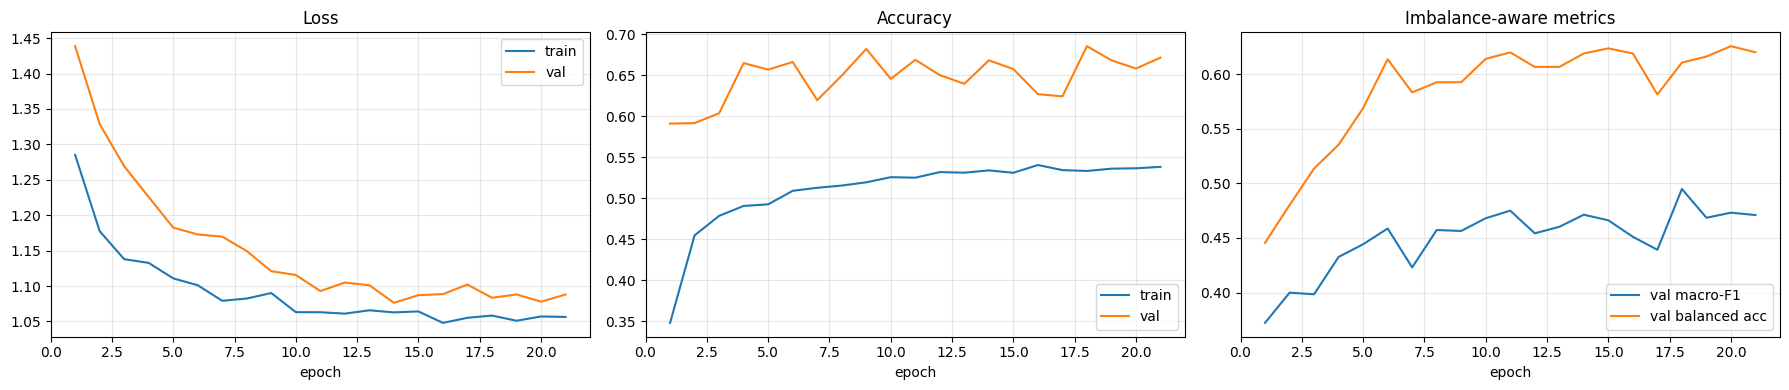

In [18]:
log = pd.read_csv(LOG_PATH)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(log['epoch'], log['train_loss'], label='train')
axes[0].plot(log['epoch'], log['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(log['epoch'], log['train_acc'], label='train')
axes[1].plot(log['epoch'], log['val_acc'],   label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(log['epoch'], log['val_macro_f1'],     label='val macro-F1')
axes[2].plot(log['epoch'], log['val_balanced_acc'], label='val balanced acc')
axes[2].set_title('Imbalance-aware metrics'); axes[2].set_xlabel('epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
out = RESULTS / 'plots' / 'augmented_resnet50_curves.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 8. Test-set evaluation — augmented model

In [19]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded best augmented checkpoint (epoch {ckpt['epoch']}, val macro-F1 {ckpt['val_macro_f1']:.4f})")

test_preds = []; test_labels = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        test_preds.extend(model(x).argmax(1).cpu().tolist())
        test_labels.extend(y.cpu().tolist())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)

test_macro_f1     = f1_score(test_labels, test_preds, average='macro', zero_division=0)
test_balanced_acc = balanced_accuracy_score(test_labels, test_preds)
test_acc          = float((test_preds == test_labels).mean())
per_class_recall  = recall_score(test_labels, test_preds, average=None,
                                  labels=list(range(N_CLASSES)), zero_division=0)

print(f'\nTEST (augmented):  acc={test_acc:.4f}  macro_f1={test_macro_f1:.4f}  balanced_acc={test_balanced_acc:.4f}')
print('\nPer-class recall (augmented):')
for c in range(N_CLASSES):
    print(f'  {CLASS_NAMES[c]:<8}{per_class_recall[c]:.3f}')

print('\nFull classification report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES,
                            digits=3, zero_division=0))

Loaded best augmented checkpoint (epoch 18, val macro-F1 0.4948)



TEST (augmented):  acc=0.6886  macro_f1=0.4925  balanced_acc=0.6026

Per-class recall (augmented):
  MEL     0.557
  NV      0.755
  BCC     0.519
  AKIEC   0.449
  BKL     0.558
  DF      0.471
  VASC    0.909

Full classification report:
              precision    recall  f1-score   support

         MEL      0.369     0.557     0.444       167
          NV      0.938     0.755     0.837      1006
         BCC      0.506     0.519     0.513        77
       AKIEC      0.393     0.449     0.419        49
         BKL      0.467     0.558     0.508       165
          DF      0.170     0.471     0.250        17
        VASC      0.323     0.909     0.476        22

    accuracy                          0.689      1503
   macro avg      0.452     0.603     0.492      1503
weighted avg      0.766     0.689     0.715      1503



## 9. Confusion matrix — augmented model

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/augmented_resnet50_confusion.png


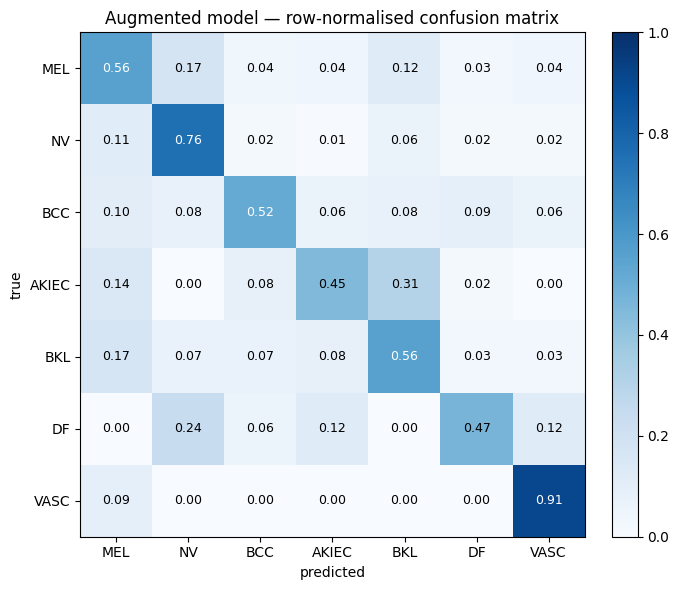

In [20]:
cm = confusion_matrix(test_labels, test_preds, labels=list(range(N_CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Augmented model — row-normalised confusion matrix')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=9)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
out = RESULTS / 'plots' / 'augmented_resnet50_confusion.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 10. THE COMPARISON — baseline vs augmented

Load the baseline model (Phase 5 output), evaluate it on the **same** test loader, then plot per-class recall side-by-side. This is the main result figure.

In [21]:
# Re-build a fresh model and load baseline weights
baseline_model = build_resnet50_classifier(
    num_classes=N_CLASSES,
    freeze_backbone=True
).to(DEVICE)
baseline_ckpt = torch.load(BASELINE_CKPT, map_location=DEVICE)
# Phase 5's checkpoint key may be 'model_state_dict' (our convention) or 'state_dict'
state_dict = baseline_ckpt.get('model_state_dict', baseline_ckpt.get('state_dict'))
baseline_model.load_state_dict(state_dict)
baseline_model.eval()
print(f"Loaded baseline checkpoint")

base_preds = []; base_labels = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        base_preds.extend(baseline_model(x).argmax(1).cpu().tolist())
        base_labels.extend(y.cpu().tolist())
base_preds  = np.array(base_preds)
base_labels = np.array(base_labels)
assert (base_labels == test_labels).all(), 'Label order mismatch — bug!'

base_macro_f1     = f1_score(base_labels, base_preds, average='macro', zero_division=0)
base_balanced_acc = balanced_accuracy_score(base_labels, base_preds)
base_acc          = float((base_preds == base_labels).mean())
base_recall       = recall_score(base_labels, base_preds, average=None,
                                  labels=list(range(N_CLASSES)), zero_division=0)

print(f'\nTEST (baseline) : acc={base_acc:.4f}  macro_f1={base_macro_f1:.4f}  balanced_acc={base_balanced_acc:.4f}')
print(f'TEST (augmented): acc={test_acc:.4f}  macro_f1={test_macro_f1:.4f}  balanced_acc={test_balanced_acc:.4f}')

# Comparison table
# Pull per-class synth counts directly from the dataset's composition table.
# `comp` (built in cell 6) is indexed by class NAME and has 'real' and possibly 'synth' columns.
def synth_count_for(class_idx):
    name = CLASS_NAMES[class_idx]
    if name not in comp.index or 'synth' not in comp.columns:
        return 0
    return int(comp.loc[name, 'synth'])

cmp = pd.DataFrame({
    'class':              CLASS_NAMES,
    'baseline_recall':    base_recall,
    'augmented_recall':   per_class_recall,
    'delta':              per_class_recall - base_recall,
    'synth_added':        [synth_count_for(c) for c in range(N_CLASSES)],
})
summary_row = pd.DataFrame([{
    'class': 'OVERALL',
    'baseline_recall':  base_balanced_acc,
    'augmented_recall': test_balanced_acc,
    'delta':            test_balanced_acc - base_balanced_acc,
    'synth_added':      sum(cmp['synth_added']),
}])
cmp_out = pd.concat([cmp, summary_row], ignore_index=True)
out_csv = RESULTS / 'logs' / 'comparison_baseline_vs_augmented.csv'
cmp_out.to_csv(out_csv, index=False)
print(f'\nsaved {out_csv}')
print('\nPer-class recall comparison:')
print(cmp_out.to_string(index=False))

Loaded baseline checkpoint

TEST (baseline) : acc=0.6939  macro_f1=0.4641  balanced_acc=0.5498
TEST (augmented): acc=0.6886  macro_f1=0.4925  balanced_acc=0.6026

saved /home/mayarn/skin-cancer/skin-lesion/results/logs/comparison_baseline_vs_augmented.csv

Per-class recall comparison:
  class  baseline_recall  augmented_recall     delta  synth_added
    MEL         0.467066          0.556886  0.089820          442
     NV         0.800199          0.755467 -0.044732            0
    BCC         0.519481          0.519481  0.000000         1280
  AKIEC         0.551020          0.448980 -0.102041         1542
    BKL         0.430303          0.557576  0.127273          462
     DF         0.352941          0.470588  0.117647         1840
   VASC         0.727273          0.909091  0.181818         1802
OVERALL         0.549755          0.602581  0.052827         7368


## 11. The main result figure

Per-class recall, baseline vs augmented. The classes the synthetic data targeted (BCC, AKIEC, VASC, DF by default) should show the biggest deltas. NV/MEL/BKL should stay roughly flat — if they collapse, the synthetic data is hurting overall calibration (a problem worth flagging in the report).

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/comparison_per_class_recall.png


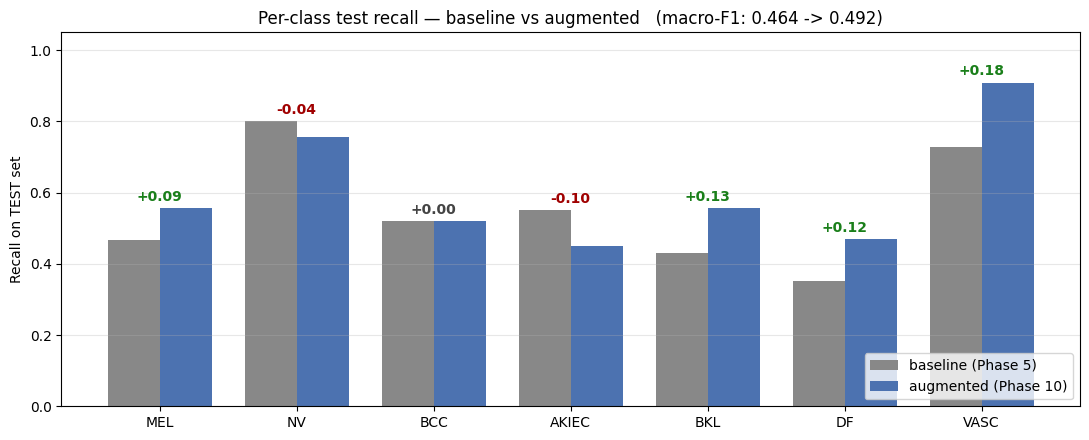

In [22]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(N_CLASSES)
w = 0.38
ax.bar(x - w/2, base_recall,     width=w, label='baseline (Phase 5)',    color='#888888')
ax.bar(x + w/2, per_class_recall, width=w, label='augmented (Phase 10)', color='#4C72B0')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Recall on TEST set')
ax.set_ylim(0, 1.05)
ax.set_title(f'Per-class test recall — baseline vs augmented   '
             f'(macro-F1: {base_macro_f1:.3f} -> {test_macro_f1:.3f})')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')

# Annotate deltas
for i in range(N_CLASSES):
    d = per_class_recall[i] - base_recall[i]
    y = max(per_class_recall[i], base_recall[i]) + 0.02
    color = '#1a7f1a' if d > 0 else ('#a00000' if d < 0 else '#444')
    sign = '+' if d >= 0 else ''
    ax.text(i, y, f'{sign}{d:.2f}', ha='center', fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
out = RESULTS / 'plots' / 'comparison_per_class_recall.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 12. What to do next

**Read the result honestly.** Three possible outcomes:

1. **Rare-class recalls go up, macro-F1 goes up, NV/majority recalls stay flat.** Best case. Write this up as the headline result. Phase 11 (Grad-CAM + failure analysis) will deepen the story.
2. **Rare-class recalls go up, but NV/majority recalls drop, macro-F1 roughly flat.** Mixed — the model traded majority-class confidence for minority-class coverage. Still a defensible result for the report; argue it on imbalance-aware metrics.
3. **Everything drops.** The synthetic samples are misleading the model. Check Phase 9 FID + visuals; if a generator's samples are mostly noise, set its class to `'none'` in `SOURCES_PER_CLASS` and re-run.

**Ablations worth running** (easy with this notebook — just edit `SOURCES_PER_CLASS` and re-run):
- cvae-only: set every class to `'cvae'`
- cgan-only: set every class to `'cgan'`
- only DF (smallest class): set everything to `'none'` except class 5
- Each ablation produces its own row of numbers; the comparison table is cheap to extend.

**Update PROJECT_STATUS.md**: mark Phase 10 ✅, record the headline macro-F1 delta and per-class deltas. Phase 11 builds on the augmented checkpoint to add Grad-CAM and a confusion-matrix delta plot.